In [6]:
import cv2
import matplotlib.pyplot as plt
import os
import os.path as osp
import numpy as np

In [7]:
PATH = "img/"
FORMAT = ".png"

In [8]:
def loadAndConvert(img_path):
    img = cv2.imread(f'{PATH + img_path}')    
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.uint8)

def loadColoured(img_path):
    img = cv2.imread(f'{PATH + img_path}')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img 
   
def showMultipleImages(imgs):
    fig, axes = plt.subplots(1, len(imgs), figsize=(12,12))
    
    for i, img in enumerate(imgs):
        axes[i].imshow(img, cmap='gray')
        axes[i].axis(False)
    plt.tight_layout()

def showImage(img):
    fig, ax = plt.subplots(figsize=(12,12))
    ax.axis(False)
    ax.imshow(img, cmap='gray')

In [71]:
IMGS = list(map(loadAndConvert, sorted(os.listdir(PATH))))

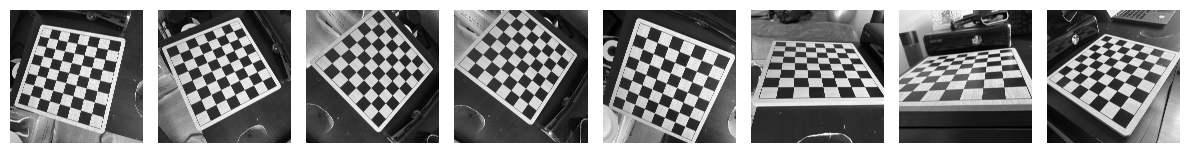

In [72]:
showMultipleImages(IMGS)

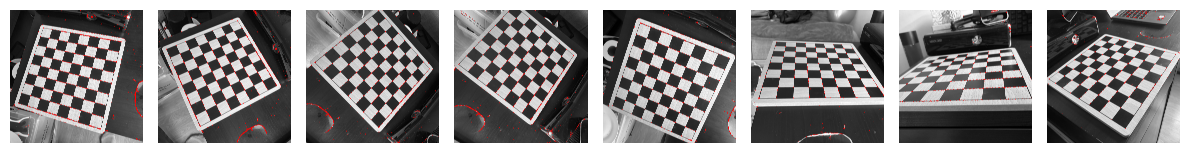

In [ ]:
def harrisCornerDetection(img):
    converted = np.float32(img)

    dest = cv2.cornerHarris(converted, 17, 21, 0, 0.01)
    dest = cv2.dilate(dest, None)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img[dest > 0.01 * dest.max()] = [255,0,0]
    
    return img

IMGS = list(map(loadAndConvert, sorted(os.listdir(PATH))))
IMGS = list(map(harrisCornerDetection, IMGS))
showMultipleImages(IMGS)

In [ ]:
BLUR = 1.4

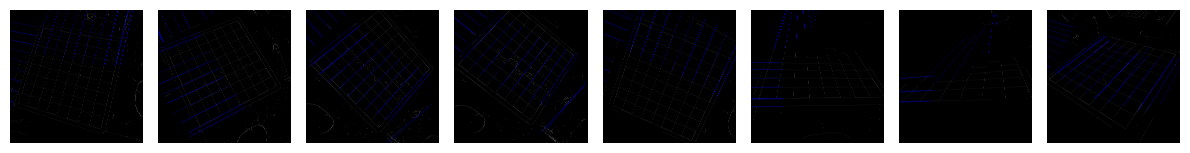

In [38]:
def blurImage(img):
    return cv2.GaussianBlur(img, (5,5), BLUR)

def cannyEdgeDetection(img):
    return cv2.Canny(img, 100, 200)

def dilateAndErodeEdges(img):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
    dilated = cv2.dilate(img, kernel, iterations=1)
    return cv2.erode(dilated, kernel, iterations=1)

def findContours(img):
    contours, hierarchy = cv2.findContours(img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)    
    contours = sorted(contours, key=lambda c: cv2.arcLength(c, True), reverse=True)
    
    sorted_contours = []
    for contour in contours:
        epsilon = 0.02 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon=epsilon, closed=True)

        if len(approx) == 4:
            sorted_contours.append(contour)

    return sorted_contours 

def drawContours(img, contours):
    return cv2.drawContours(img, contours, contourIdx=-1, color=(255,0,0), thickness=3)

def drawContoursOnBlank(img, contours):
    blank = np.zeros_like(img, np.uint8)
    return cv2.drawContours(blank, contours, contourIdx=-1, color=(255,0,0), thickness=3)

def drawHoughLines(img):
    lines = cv2.HoughLines(img, 1, np.pi/180, 300)
    out = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    if lines is None:
        return out

    for line in lines:
        rho, theta = line[0]
        
        a = np.cos(theta)
        b = np.sin(theta)
        
        x0 = a*rho
        y0 = b*rho

        x1 = int(x0 + 1000*(-b))
        y1 = int(y0 + 1000*(a))

        x2 = int(x0 - 1000*(-b))
        y2 = int(y0 - 1000*(a))

        cv2.line(out, (x1, y1), (x2, y2), (0,0,255), 3)

    return out

IMGS = list(map(loadAndConvert, sorted(os.listdir(PATH))))
blurred = list(map(blurImage, IMGS))
edges = list(map(cannyEdgeDetection, blurred))
eroded = list(map(dilateAndErodeEdges, edges))
contours = list(map(findContours, eroded))
blank = list(map(drawContoursOnBlank, IMGS, contours))
drawn = list(map(drawHoughLines, edges))

showMultipleImages(drawn)


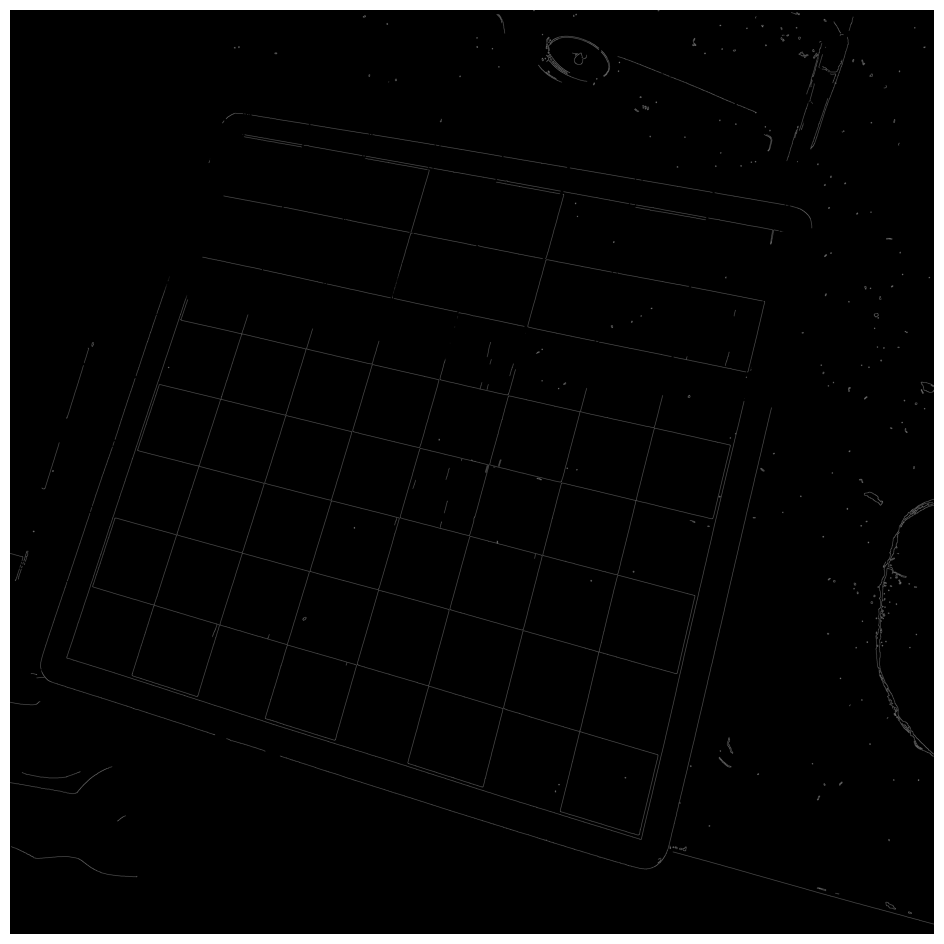

In [32]:
showImage(drawn[0])
